# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Hana Talitha Syahda
- **Email:** hynanana03@gmail.com
- **ID Dicoding:** 	CDCC229D6X2232

## Menentukan Pertanyaan Bisnis

- State mana yang memiliki total revenue dan jumlah transaksi tertinggi selama periode Januari – Desember 2018, serta berapa kontribusinya terhadap total revenue?

- Bagaimana hubungan antara rata-rata review score dengan total revenue pada setiap kategori produk selama periode Januari – Desember 2018, serta seberapa besar nilai korelasinya?

## Import Semua Packages/Library yang Digunakan

In [480]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## Data Wrangling

### Gathering Data

In [481]:
customers_df  = pd.read_csv('customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- customers_id =  ID unik untuk setiap pelanggan, digunakan untuk mengidentifikasi pelanggan dalam sistem.
- customer_unique_id = ID unik pelanggan yang menghubungkan beberapa transaksi dari pelanggan yang sama, berguna untuk menganalisis frekuensi pembelian dan loyalitas pelanggan.
- customer_zip_code_prefix = Kode pos dari alamat pelanggan, dapat digunakan untuk segmentasi pasar dan menganalisis pelanggan berdasarkan lokasi geografis.
- customer_city = Nama kota tempat tinggal pelanggan, membantu untuk menganalisis tren pembelian berdasarkan lokasi atau kota.
- customer_state = Kode negara bagian tempat pelanggan berada, membantu dalam analisis konsentrasi pelanggan di wilayah tertentu.

In [482]:
order_items_df  = pd.read_csv('order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- order_id = ID unik untuk setiap pesanan, digunakan untuk menganalisis jumlah pesanan dalam periode tertentu dan menghubungkan data dengan dataset lain (misalnya, data pembayaran dan pengiriman).
- order_item_id = ID unik untuk setiap item dalam pesanan, berguna sebagai nomor urut item dalam satu pesanan dan membantu menganalisis jumlah produk yang terlibat dalam satu transaksi.
- product_id = ID unik produk yang dipesan, membantu untuk melihat tren pembelian berdasarkan kategori produk dan mengidentifikasi produk yang lebih sering dibeli oleh pelanggan.
- seller_id = ID unik seller/penjual yang menjual produk. Data ini memungkinkan untuk mengetahui penjual mana yang memiliki produk dengan jumlah permintaan tinggi dan menganalisis kinerja penjual dalam hal produk yang mereka tawarkan.
- shipping_limit_date = Tanggal batas waktu bagi seller/penjual untuk mengirimkan pesanan kepada pelanggan. Memberikan gambaran tentang ketepatan waktu penjual dalam memenuhi batas waktu pengiriman.
- price = Harga per item produk, digunakan untuk menghitung pendapatan per item dan menganalisis harga produk dalam transaksi.
- freight_value = Biaya pengiriman produk, digunakan untuk menganalisis biaya logistik per pesanan dan melihat pengaruh biaya pengiriman terhadap biaya total transaksi.

In [483]:
order_reviews_df  = pd.read_csv('order_reviews_dataset.csv')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- review_id = ID unik untuk setiap ulasan, digunakan untuk mengidentifikasi ulasan secara unik.
- order_id = ID unik pesanan yang menghubungkan ulasan dengan pesanan tertentu untuk dilihat hubungan anatar pelanggan dengan produk yang dipesan.
- review_score = Skor ulasan dari 1 hingga 5, berguna untuk gambaran umum tentang kepuasan pelanggan terhadap produk yang dibeli.
- review_comment_title = Judul komentar ulasan, digunakan untuk memberi gambaran umum atau ringaksan dari isi ulasan.
- review_comment_message = Isi komentar ulasan. Memberikan informasi rinci tentang pengalaman pelanggan terkait produk.
- review_creation_date = Tanggal ulasan dibuat, membantu untuk melacak waktu ulasan yang diberikan.
- review_answer_timestamp = Tanggal dan waktu ulasan dijawab/disetujui sistem, digunakan untuk menganalisis kecepatan respons penjual terhadap umpan balik pelanggan.

In [484]:
orders_dataset_df  = pd.read_csv('orders_dataset.csv')
orders_dataset_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- order_id = ID unik pesanan yang menghubungkan data pesanan dengan dataset lainnya untuk analisis lebih lanjut.
- customer_id = ID unik pelanggan yang menghubungkan pesanan dengan pelanggan tertentu, berguna untuk menganalisis perilaku pembelian pelanggan.
- order_status = Status pesanan, seperti delivered, shipped, canceled, dll., yang memberi gambaran tentang status pengiriman dan apakah pesanan sudah sampai ke pelanggan atau belum.
- order_purchase_timestamp = Tanggal dan waktu pesanan dibuat, memeberikan wawasan tentang tren pembelian pelanggan dan pola waktu transaksi.
- order_approved_at = Waktu persetujuan pembayaran, berguna untuk melihat kecepatan proses pesanan dalam sistem dan apakah ada penundaan dalam tahap persetujuan.
- order_delivered_carrier_date = Waktu pesananan diserahkan ke kurir/logistik. Memberikan informasi mengenai kecepatan pengiriman dan seberapa cepat kurir mengirimkan pesanan ke pelanggan.
- order_delivered_customer_date = Waktu penanan diterima pelanggan, memberikan gambaran tentang lama waktu pengiriman yang diperlukan dari proses pemesanan hingga barang diterima pelanggan.
- order_estimated_delivery_date = Perkiraan tanggal pengiriman yang ditentukan oleh sistem, digunakan untuk menganalisis ketepatan waktu pengiriman dan apakah pengiriman dilakukan sesuai dengan estimasi.

In [485]:
product_category_name_translation_df  = pd.read_csv('product_category_name_translation.csv')
product_category_name_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- product_category_name = Nama kategori dalam bahasa Portugis. Memberikan informasi tentang kategori produk yang digunakan di platform e-commerce Brasil.
- product_category_name_english = Nama kategori produk yang sudah diterjemahkann ke bahasa Inggris, sehingga kategori produk dapat dianalisis secara global atau internasional.

In [486]:
products_dataset_df  = pd.read_csv('products_dataset.csv')
products_dataset_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- product_id = ID unik untuk setiap produk yang berguna untuk  mengidentifikasi produk secara individual dan melacak performa penjualan per produk.
- product_category_name = Nama kategori produk dalam bahasa Portugis, berguna untuk mengklasifikasikan produk berdasarkan kategori dan menganalisis tren pembelian di berbagai kategori produk.
- product_name_lenght	= Panjang karakter dari nama produk, digunakan untuk menganalisis pengaruh panjang nama produk terhadap penjualan.
- product_description_lenght = Panjang karakter dari deskripsi produk, memberikan insight tentang seberapa detail deskripsi produk dan apakah deskripsi yang lebih panjang berhubungan dengan kepuasan pelanggan.
- product_photos_qty = Jumlah foto produk yang diunggah, dapat digunakan untuk meningkatkan peluang pembelian, karena pelanggan bisa melihat produk lebih detail dan membuat keputusan yang lebih yakin.
- product_weight_g = Berat produk dalam gram, berguna untuk membantu menganalisis pengaruh berat produk terhadap biaya pengiriman.
- product_length_cm = Panjang produk dalam centimeter, digunakan untuk menganalisis proses pengemasan dan pengiriman, serta untuk memastikan produk dapat diproses dengan benar.
- product_height_cm = Tinggi produk dalam centimeter, digunakan untuk menganalisis proses pengemasan dan pengiriman, serta untuk memastikan produk dapat diproses dengan benar.
- product_width_cm = Lebar produk dalam centimeter, digunakan untuk menganalisis proses pengemasan dan pengiriman, serta untuk memastikan produk dapat diproses dengan benar.

### Assessing Data

In [487]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


**Insight:**
- Jumlah Baris = Terdapat 99441 baris yang menunjukkan dataset pelanggan cukup besar, mencakup banyak kode.
- Jumlah Kolom = Terdapat 5 kolom, yang menunjukkan dataset ini memiliki struktur yang sederhana.
- Missing Values = Tidak terdapat missing values, yang menandakan data bersih dan siap digunakan.
- Tipe Data = Terdapat beberapa tipe data, yaitu int64 dan object.

In [488]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


**Insight:**
- Missing Values = Tidak terdapat missing value pada seluruh kolom.

In [489]:
print("Jumlah duplikasi: "), customers_df.duplicated().sum()

Jumlah duplikasi: 


(None, np.int64(0))

**Insight:**
- Duplikasi Data = Tidak terdapat duplikasi baris pada dataset.


In [490]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight:**
- Kelengkapan Data = Terdapat 99441 entri, yang menunjukkan seluruh data kode pos pada dataset ini lengkap.
- Sebaran Kode Pos = Kode pos pelanggan berkisar dari 1003 hingga 99990, dengan mean 35137 dan standar deviasi 29798. Hal ini menunjukkan variasi lokasi pelanggan yang sangat luas di seluruh Brasil.
- Distribusi Data = Median (24416) lebih rendah dibandingkan mean (35137), yang menunjukkan bahwa  data terdistribusi condong ke kanan (right-skewed).
- Potensi Analisis = Dataset ini dapat digabungkan dengan dataset geolocation untuk melakukan analisis berdasarkan lokasi geografis.


In [491]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Insight:**
- Jumlah Baris = Terdapat 112650 baris, yang menunjukkan data item pesanan cukup besar.
- Jumlah Kolom = Terdapat 7 kolom, yang menunjukkan dataset cukup lengkap.
- Missing Values = Tidak terdapat missing values, yang menandakan data bersih dan siap digunakan.
- Tipe Data = Terdapat beberapa tipe data, yaitu int64, object, float64.

In [492]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


**Insight:**
- Missing Values = Tidak terdapat missing value pada seluruh kolom.

In [493]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Duplikasi Data = Tidak terdapat duplikasi baris dalam dataset.


In [494]:
order_items_df[['price', 'freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


**Insight:**
- Variasi Harga Produk = Variasi harga produk memiliki rentang dari 0.850000 hingg 6735.000000. Hal ini menunjukkan adanya perbedaan harga yang signifikan antar produk.
- Distribusi Harga = Nilai median (74.990000) lebih rendah dibandingkan mean (120.653739), yang menunjukkan bahwa distribusi harga cenderung condonng ke kanan (right-skewed).
- Biaya Pengiriman = Biaya pengiriman memiliki mean 19.990320, menunjukkan sebagian besar nilai tidak terlalu besar, tetapi ada beberapa kasus dengan biaya pengiriman yang jauh lebih tinggi (409.680000).
- Sebaran Data = Harga dan biaya pengiriman memiliki variasi yang cukup besar, sehingga kemungkinan terdapat outlier dalam dataset.

In [495]:
orders_dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Insight:**
- Jumlah Baris = Terdapat 99441 baris, yang menunjukkan data item pesanan cukup besar.
- Jumlah Kolom = Terdapat 8 kolom, yang menunjukkan dataset cukup lengkap.
- Missing Values = Terdapat beberapa missing values pada beberapa kolom, yaitu order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date. Hal ini menunjukkan bahwa tidak semua pesanan memiliki informasi yang lengkap.
- Tipe Data = Seluruh kolom bertipe data object.

In [496]:
orders_dataset_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**
- Missing Values = Terdapat missing values pada beberapa kolom, yaitu order_approved_at (160), order_delivered_carrier_date (1783), dan order_delivered_customer_date (2965). Hal ini menunjukkan bahwa tidak semua pesanan memiliki informasi yang lengkap.

In [497]:
print("Jumlah duplikasi: ", orders_dataset_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Duplikasi Data = Tidak terdapat duplikasi baris pada dataset.


In [498]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


**Insight:**
- Jumlah Baris = Terdapat 99224  baris, yang menunjukkan jumlah data review pelanggan cukup besar.
- Jumlah Kolom = Terdapat 7 kolom, yang menunjukkan struktur dataset sederhana.
- Missing Values = Terdapat missing values pada beberapa kolom, yaitu review_comment_title dan review_comment_message. Hal ini menunjukkan bahwa tidak semua pelanggan memberikan judul atau isi komentar, meskipun tetap memberikan review.
- Tipe Data = Terdapat beberapa tipe data, yaitu int64 dan object.

In [499]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Insight:**
- Missing Values = Terdapat missing values yang cukup besar pada kolom review_comment_title (87656) dan kolom review_comment_message (58247). Hal ini menunjukkan bahwa sebagian besar pelanggan tidak memberikan komentar tertulis, namun tetap memberikan review.

In [500]:
print("Jumlah duplikasi: ", order_reviews_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Duplikasi Data = Tidak terdapat duplikasi baris pada dataset.


In [501]:
order_reviews_df['review_score'].describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight:**
- Rata-rata Review = Nilai mean review berada pada 4.086421, yang menunjukkan bahwa secara umum pelanggan memberikan penilaian yang cukup baik.
- Distribusi Review = Nilai median berada di angka 5.000000, yang berarti sebagian pelanggan memberikan score tinggi.
- Pola Data = Nilai mean yang sedikit lebih rendah dibandingkan median menunjukkan adanya beberapa review rendah yang memengaruhi rata-rata.

In [502]:
products_dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**
- Jumlah Baris = Terdapat 32951 baris, yang menunjukkan jumlah data produk cukup banyak dan beragam.
- Jumlah Kolom = Terdapat 9 kolom, yang menunjukkan dataset cukup lengkap.
- Missing Values = Terdapat missing values pada beberapa kolom, yaitu product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, dan product_width_cm. Hal ini menunjukkan bahwa tidak semua produk memiliki informasi yang lengkap.
- Tipe Data = Terdapat beberapa tipe data, yaitu object dan float64.

In [503]:
products_dataset_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


**Insight:**
- Missing Values = Terdapat 610 missing values pada kategori dan metadata pada kolom product_category_name, product_name_lenght, product_description_lenght, dan product_photos_qty. Kemudian, terdapat pula 2 missing values pada dimensi dan berat produk pada kolom product_weight_g, product_length_cm, product_height_cm, dan product_width_cm.

In [504]:
print("Jumlah duplikasi: ", products_dataset_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Duplikasi Data = Tidak terdapat duplikasi baris pada dataset.


In [505]:
products_dataset_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- product_name_lenght = Memiliki nilai mean 48.476949 dengan median 51.000000 karakter. Rentang nama produk berkisar antara 5.000000 - 76.000000 karakter, dengan standar deviasi 10.245741. Hal ini menunjukkan variasi nama produk relatif kecil.
- product_description_lenght = Memiliki nilai mean 771.495285 dengan median 595.000000 karakter. Karena nilai median lebih kecil dibandingkan mean, hal ini menunjukkan distribusi deskripsi produk condong ke kanan (right-skewed). Terdapat produk dengan deskripsi minimal hanya 4 karakter.
- product_photos_qty = Memiliki nilai mean 2.188986 foto dengan median 1.000000 foto. Mayoritas produk (75%) memiliki 1.000000 - 3.000000 foto dan terdapat maksimal foto yang tercapai yaitu 20 foto.
- product_weight_g = Memiliki nilai mean 2276.472488 gram dengan median 700.000000 gram. Karena nilai mean lebih kecil dibandingkan standar deviasi (4282.038731) maka distribusi berat produk condong ke kanan (right-skewed). Terdapat produk dengan berat 0 gram dan produk terberat mencapai 40425.000000 gram.
- product_length_cm = Memilini nilai mean 30.815078 cm dengan median 25.000000 cm, yang menunjukkan ukuran panjang produk cukup bervariasi.
- product_height_cm = Memiliki nilai mean 16.937661 cm dan median 13.000000 cm, yang menunjukkan tinggi produk cenderung bervariasi.
- product_width_cm = Memiliki nilai mean 23.196728 cm dengan median 20.000000 cm, yang menujukkan lebar produk cukup beragam.

In [506]:
product_category_name_translation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


**Insight:**
- Jumlah Baris = Terdapat 71 baris, yang menunjukkan jumlah data kategori produk tidak terlalu banyak dan terbatas.
- Jumlah Kolom = Terdapat 2 kolom, yang menunjukkan dataset ini memiliki struktur sederhana
- Missing Values = Tidak terdapat missing values, sehingga data lengkap dan siap digunakan.
- Tipe Data = Hanya terdapat satu tipe data, yaitu object.

In [507]:
product_category_name_translation_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


**Insight:**
- Missing Values = Tidak terdapat missing value pada seluruh kolom.

In [508]:
print("Jumlah duplikasi: ", product_category_name_translation_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Duplikasi Data = Tidak terdapat duplikasi baris pada dataset.


In [509]:
customers_df[['customer_id', 'customer_unique_id']].nunique()

,0
customer_id,99441
customer_unique_id,96096


**Insight:**
- Terdapat 99441 **'customer_id'** dan 96096 **'customer_unique_id'**, yang menunjukkan bahwa jumlah ID transaksi lebih banyak dibandingkan jumlah pelanggan unik.
- Pola Transaksi Customer = Perbedaan **'customer_id'** dan **'customer_unique_id'** menunjukkan bahwa terdapat pelanggan yang melakukan lebih dari satu kali transaksi.


In [510]:
customers_df[['customer_city', 'customer_state']].nunique()

,0
customer_city,4119
customer_state,27


**Insight:**
- Pelanggan berasal dari 4119 kota, menunjukkan data mencakup wilayah yang cukup luas.
- Terdapat 27 state dalam dataset, menandakan bahwa distribusi pelanggan mencakup hampir seluruh wilayah di Brasil.

In [511]:
orders_dataset_df['order_purchase_timestamp'].min(),
orders_dataset_df['order_purchase_timestamp'].max()

'2018-10-17 17:30:18'

**Insight:**
- Data transaksi mencakup periode hingga tahun 2018, sehingga analisis difokuskan pada tahun tersebut agar lebih relevan.

### Cleaning Data

In [512]:
df = orders_dataset_df.merge(order_items_df, on='order_id') \
           .merge(customers_df, on='customer_id') \
           .merge(order_reviews_df, on='order_id') \
           .merge(products_dataset_df, on='product_id') \
           .merge(product_category_name_translation_df, on='product_category_name', how='left')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-08-08 18:37:50,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,2018-08-22 19:07:58,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,2017-12-05 19:21:58,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02-18 13:02:51,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


**Insight:**
- Data dari beberapa tabel digabungkan menjadi satu dataframe, sehingga informasi seperti transaksi, customer, produk, dan review dapat dianalisis secara menyeluruh dalam satu dataset.
- Data yang telah digabungkan memudahkan proses analisis hubungan antara lokasi customer, kategori produk, harga, dan review.

In [513]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

**Insight:**
- Mengubah kolom **'order_purchase_timestamp'** menjadi format datetime sehingga dapat digunakan untuk analisis berbasis waktu.

In [514]:
df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1184
order_delivered_customer_date,2360
order_estimated_delivery_date,0
order_item_id,0
product_id,0


**Insight:**
- Terdapat missing values pada kolom **'order_approved_at'**, **'order_delivered_carrier_date'**, **'order_delivered_customer_date'**, **'review_comment_title'**, **'review_comment_message'**, **'product_category_name'**, **'product_name_lenght'**, **'product_description_lenght'**, **'product_photos_qty'**, **'product_weight_g'**, **'product_length_cm'**, **'product_height_cm'**, **'product_width_cm'**, dan **'product_category_name_english'**. Karena missing values tersebut pada kolom yang tidak akan digunakan secara langsung dalam analisis utama, maka dapat diabaikan atau tidak diprioritaskan dalam penanganannya.

In [515]:
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')

**Insight:**
- Mengisi missing values pada kategori produk dengan 'Unknown'.

In [516]:
df = df[['order_id', 'order_purchase_timestamp', 'customer_id', 'customer_state',
         'product_id', 'product_category_name_english', 'price', 'review_score']]

**Insight:**
- Untuk memfokuskan analisis pada kolom yang relevan, dilakukan proses filter sehingga dataset menjadi lebih terstruktur dan mudah dianalisis.

In [517]:
df_2018 = df[df['order_purchase_timestamp'].dt.year == 2018]

**Insight:**
- Data difilter untuk mengambil transaksi pada tahun 2018 agar analisis lebih fokus dan relevan.

In [518]:
df_2018.to_csv('main_data.csv', index=False)

**Insight:**

- Menyimpan hasil cleaning ke CSV baru.

## Exploratory Data Analysis (EDA)

### Explore ...

In [519]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 8 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112372 non-null  object        
 1   order_purchase_timestamp       112372 non-null  datetime64[ns]
 2   customer_id                    112372 non-null  object        
 3   customer_state                 112372 non-null  object        
 4   product_id                     112372 non-null  object        
 5   product_category_name_english  112372 non-null  object        
 6   price                          112372 non-null  float64       
 7   review_score                   112372 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 6.9+ MB


In [520]:
df.head()

,order_id,order_purchase_timestamp,customer_id,customer_state,product_id,product_category_name_english,price,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,9ef432eb6251297304e76186b10a928d,SP,87285b34884572647811a353c7ac498a,housewares,29.99,4
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,b0830fb4747a6c6d20dea0b8c802d7ef,BA,595fac2a385ac33a80bd5114aec74eb8,perfumery,118.70,4
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,41ce2a54c0b03bf3443c3d931a367089,GO,aa4383b373c6aca5d8797843e5594415,auto,159.90,5
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,f88197465ea7920adcdbec7375364d82,RN,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,8ab97904e6daea8866dbdbc4fb7aad2c,SP,65266b2da20d04dbe00c5c2d3bb7859e,stationery,19.90,5


In [521]:
df.isna().sum()

,0
order_id,0
order_purchase_timestamp,0
customer_id,0
customer_state,0
product_id,0
product_category_name_english,0
price,0
review_score,0


In [522]:
df.duplicated().sum()

np.int64(10517)

In [523]:
df = df.drop_duplicates()

In [524]:
df.describe()

,order_purchase_timestamp,price,review_score
count,101855,101855.000000,101855.000000
mean,2017-12-31 22:48:21.019164416,124.185958,4.075293
min,2016-09-04 21:15:19,0.850000,1.000000
25%,2017-09-12 22:02:40,40.000000,4.000000
50%,2018-01-19 15:17:20,78.640000,5.000000
75%,2018-05-04 23:29:55,139.000000,5.000000
max,2018-09-03 09:06:57,6735.000000,5.000000
std,NaN,187.498782,1.354315


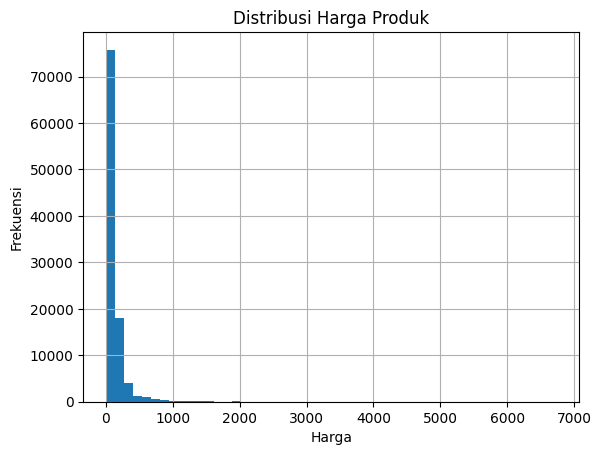

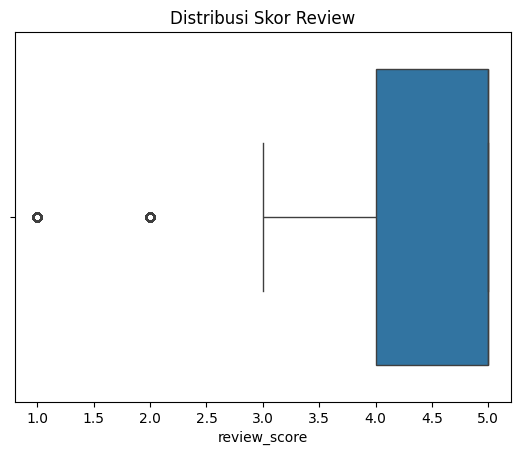

In [525]:
# Visualisasi harga produk
df['price'].hist(bins=50)
plt.title('Distribusi Harga Produk')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi skor review
sns.boxplot(x=df['review_score'])
plt.title('Distribusi Skor Review')
plt.show()

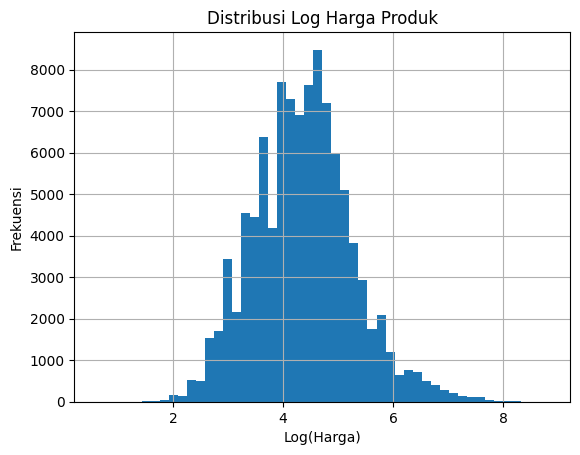

In [526]:
df['log_price'] = np.log(df['price'] + 1)
df['log_price'].hist(bins=50)
plt.title('Distribusi Log Harga Produk')
plt.xlabel('Log(Harga)')
plt.ylabel('Frekuensi')
plt.show()

**Insight:**
- Pada visualisasi harga terlihat ada skala yang besar, dengan harga lebih dari 4000, yang menunjukkan adanya outliers. Perbaikan outliers dapat dilakukan dengan menggunakan log-transformasi.

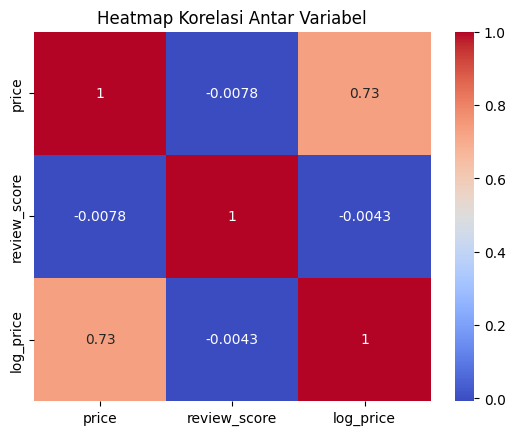

In [527]:
# Memilih hanya kolom numerik
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Hitung korelasi antar fitur numerik
correlation_matrix = numeric_df.corr()

# Visualisasi korelasi
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

In [528]:
category_analysis = df.groupby('product_category_name_english').agg({'price': 'mean', 'review_score': 'mean'})
category_analysis.corr()

,price,review_score
price,1.000000,0.031412
review_score,0.031412,1.000000


**Insight**
- Pada visualisasi harga dan skor review hasilnya menunjukkan korelasi yang sangat lemah. Hal ini dapat ditangani dengan menganalisis apakah ada variabel lain yang lebih berhubungan dengan pendapatan atau skor review. Pasa kasus ini variabel lain yang digunakan, yaitu variabel kategori produk.

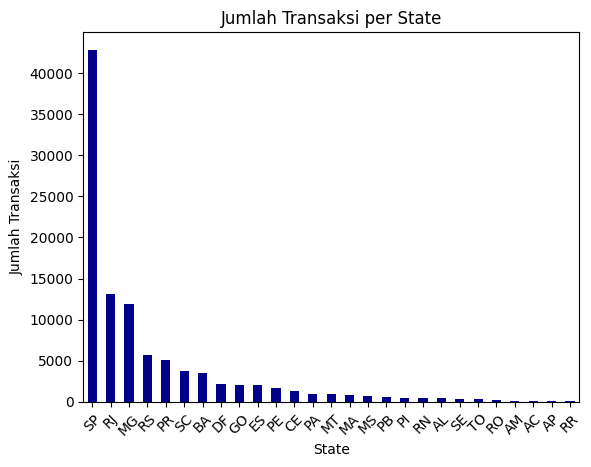

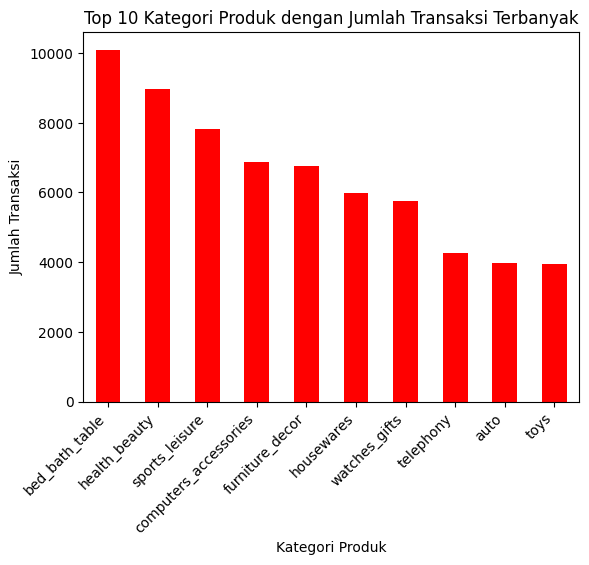

In [529]:
# Visualisasi jumlah transaksi per state
state_counts = df['customer_state'].value_counts()
state_counts.plot(kind='bar', color='darkblue', title='Jumlah Transaksi per State')
plt.xlabel('State')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.show()

# Visualisasi jumlah transaksi per kategori produk
top_categories = df['product_category_name_english'].value_counts().head(10)
top_categories.plot(kind='bar', color='red', title='Top 10 Kategori Produk dengan Jumlah Transaksi Terbanyak')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight:**
- Berdasarkan hasil analisis, terlihat bahwa revenue antar state tidak merata. Hal ini menunjukkan bahwa aktivitas transaksi lebih banyak terjadi di wilayah tertentu, sehingga state dengan revenue tinggi dapat menjadi prioritas dalam pengembangan bisnis.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

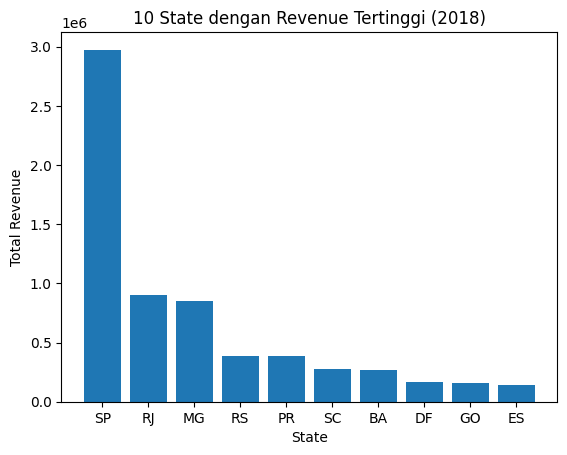

In [530]:
top_state = state_analysis.head(10)
plt.figure()
plt.bar(top_state['state'], top_state['total_revenue'])
plt.title('10 State dengan Revenue Tertinggi (2018)')
plt.xlabel('State')
plt.ylabel('Total Revenue')
plt.show()

### Pertanyaan 2:

In [531]:
print(category_analysis.columns)

Index(['price', 'review_score'], dtype='object')


In [532]:
category_analysis = df_2018.groupby('product_category_name_english').agg({
    'review_score': 'mean',
    'price': 'sum'
}).reset_index()

category_analysis.columns = ['category', 'avg_review_score', 'total_revenue']

In [533]:
print('avg_review_score' in category_analysis.columns)

True


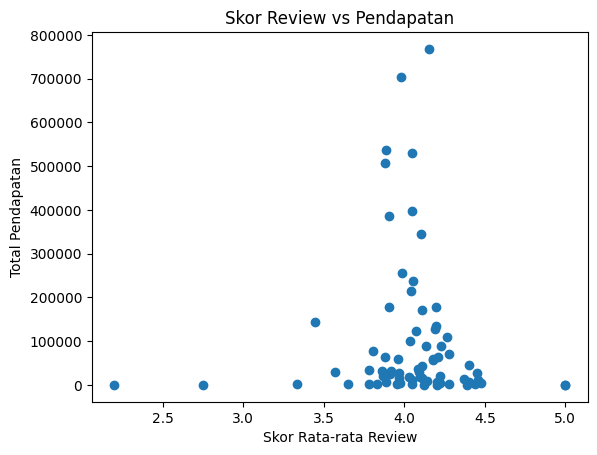

In [534]:
x = category_analysis['avg_review_score']
y = category_analysis['total_revenue']

plt.figure()
plt.scatter(x, y)
plt.title('Skor Review vs Pendapatan')
plt.xlabel('Skor Rata-rata Review')
plt.ylabel('Total Pendapatan')
plt.show()

**Insight:**
- Visualisasi Pertanyaan 1 = Berdasarkan visualisasi menggunakan bar chart, terlihat bahwa state SP mendominasi total revenue dengan selisih yang signifikan dibandingkan state lainnya. Hal ini menunjukkan bahwa pendapatan tidak merata antar state, dengan beberapa state memberikan kontribusi yang jauh lebih besar.
- Visualisasi Pertanyaan 2 = Berdasarkan visualisasi menggunakan scatter plot, tidak terlihat hubungan yang jelas antara skor rata-rata review dan total pendapatan. Hal ini menunjukkan bahwa faktor lain, seperti harga produk atau kategori produk, mungkin lebih berpengaruh terhadap pendapatan daripada skor review.

## Analisis Lanjutan (Time Series)

In [535]:
df = pd.read_csv('main_data.csv')

In [536]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.month
monthly_revenue = df.groupby('month')['price'].sum()
monthly_revenue

,price
month,
1,945497.44
2,846577.41
3,976152.79
4,991830.11
5,990416.65
6,863742.35
7,885015.34
8,850041.18
9,145.00


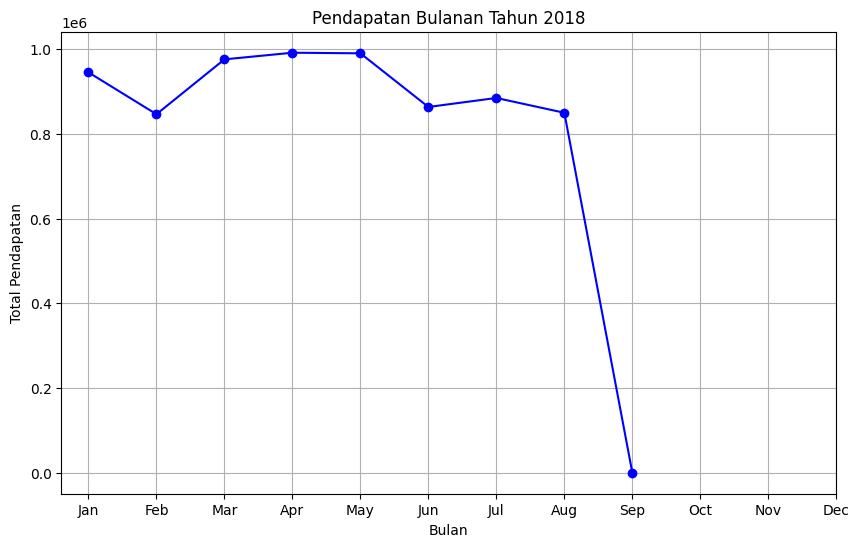

In [537]:
plt.figure(figsize=(10,6))
monthly_revenue.plot(kind='line', marker='o', color='b')
plt.title('Pendapatan Bulanan Tahun 2018')
plt.xlabel('Bulan')
plt.ylabel('Total Pendapatan')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

**Insight:**
- Berdasarkan hasil analisis time series, visualisasi pendapatan bulanan menunjukkan adanya fluktuasi pendapatan yang jelas sepanjang tahun 2018. Bulan-bulan tertentu menunjukkan peningkatan yang signifikan, yang mungkin dipengaruhi oleh faktor musiman atau promosi tertentu.

## Conclusion

- Conclution pertanyaan 1 = Analisis menunjukkan bahwa distribusi jumlah pesanan dan kontribusi pendapatan tidak merata di seluruh wilayah Brasil. Sebagian besar pesanan dan pendapatan terkonsentrasi di beberapa state seperti São Paulo (SP) dan Rio de Janeiro (RJ). Oleh karena itu, strategi pemasaran yang lebih terfokus perlu diterapkan untuk memperluas penetrasi pasar di state lain yang memiliki kontribusi lebih rendah.
- Conclution pertanyaan 2 = Meskipun kategori produk dengan kontribusi pendapatan terbesar tidak selalu memiliki skor ulasan pelanggan tertinggi, produk dengan harga lebih tinggi sering kali tetap menghasilkan pendapatan yang signifikan. Produk dengan skor ulasan rendah juga dapat memberi kontribusi besar pada pendapatan, tergantung pada faktor harga dan popularitas pasar. Oleh karena itu, sangat penting untuk menyeimbangkan antara kepuasan pelanggan dan pengelolaan produk dengan harga tinggi untuk memaksimalkan pendapatan.